In [ ]:
# imports
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Get Fruityvice API
url = "https://www.fruityvice.com"
endpoint = "/api/fruit/all"
resp = requests.get(url + endpoint)

if resp.status_code == 200:
    fruit_data = resp.json()
else:
    print("Failed to retrieve data.")

In [ ]:
# Create new pandas DataFrame to hold fruit data
fruit_df = pd.DataFrame(fruit_data)
df_nutrients = pd.json_normalize(fruit_df['nutritions'])
fruit_df = pd.concat([fruit_df, df_nutrients], axis=1)
fruit_df.drop(columns=['nutritions'], inplace=True)

fruit_df.head()

,name,id,family,order,genus,calories,fat,sugar,carbohydrates,protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.0,18.0,18.0,0.0
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.4,5.4,5.5,0.8
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.2,17.2,22.0,1.0
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.2,2.6,3.9,0.9
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.1,10.0,15.0,0.4


In [ ]:
# Use info() to check the contents and columns of the dataset
fruit_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           49 non-null     object 
 1   id             49 non-null     int64  
 2   family         49 non-null     object 
 3   order          49 non-null     object 
 4   genus          49 non-null     object 
 5   calories       49 non-null     int64  
 6   fat            49 non-null     float64
 7   sugar          49 non-null     float64
 8   carbohydrates  49 non-null     float64
 9   protein        49 non-null     float64
dtypes: float64(4), int64(2), object(4)
memory usage: 4.0+ KB


In [ ]:
# Drop columns that are irrelevant
columns_drop = ['order', 'genus', 'fat', 'protein']
fruit_df = fruit_df.drop(columns=columns_drop)
fruit_df.head()


,name,id,family,calories,sugar,carbohydrates
0,Persimmon,52,Ebenaceae,81,18.0,18.0
1,Strawberry,3,Rosaceae,29,5.4,5.5
2,Banana,1,Musaceae,96,17.2,22.0
3,Tomato,5,Solanaceae,74,2.6,3.9
4,Pear,4,Rosaceae,57,10.0,15.0


In [ ]:
# Create a new column to store calories to sugar ratio, round to 1 decimal place to keep consistency
fruit_df['cal_sugar_ratio'] = round(fruit_df['calories'] / fruit_df['sugar'], 1)

# Create a new column to store calories to carbs ratio, round to 1 decimal place to keep consistency
fruit_df['cal_carb_ratio'] = round(fruit_df['calories'] / fruit_df['carbohydrates'], 1)

fruit_df.head()

,name,id,family,calories,sugar,carbohydrates,cal_sugar_ratio,cal_carb_ratio
0,Persimmon,52,Ebenaceae,81,18.0,18.0,4.5,4.5
1,Strawberry,3,Rosaceae,29,5.4,5.5,5.4,5.3
2,Banana,1,Musaceae,96,17.2,22.0,5.6,4.4
3,Tomato,5,Solanaceae,74,2.6,3.9,28.5,19.0
4,Pear,4,Rosaceae,57,10.0,15.0,5.7,3.8


In [ ]:
fruit_df

,name,id,family,calories,sugar,carbohydrates,cal_sugar_ratio,cal_carb_ratio
0,Persimmon,52,Ebenaceae,81,18.00,18.00,4.5,4.5
1,Strawberry,3,Rosaceae,29,5.40,5.50,5.4,5.3
2,Banana,1,Musaceae,96,17.20,22.00,5.6,4.4
3,Tomato,5,Solanaceae,74,2.60,3.90,28.5,19.0
4,Pear,4,Rosaceae,57,10.00,15.00,5.7,3.8
5,Durian,60,Malvaceae,147,6.75,27.10,21.8,5.4
6,Blackberry,64,Rosaceae,40,4.50,9.00,8.9,4.4
7,Lingonberry,65,Ericaceae,50,5.74,11.30,8.7,4.4
8,Kiwi,66,Actinidiaceae,61,9.00,15.00,6.8,4.1
9,Lychee,67,Sapindaceae,66,15.00,17.00,4.4,3.9


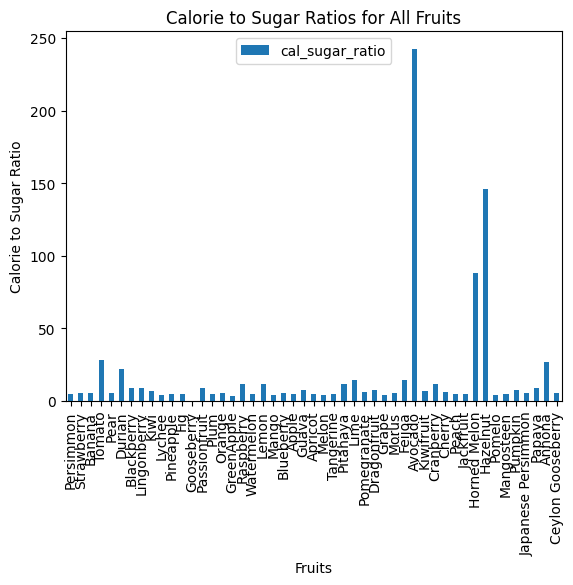

In [ ]:
fruit_df.plot.bar(x = 'name', y = 'cal_sugar_ratio')
plt.xlabel('Fruits')
plt.ylabel('Calorie to Sugar Ratio')
plt.title('Calorie to Sugar Ratios for All Fruits')
plt.show()

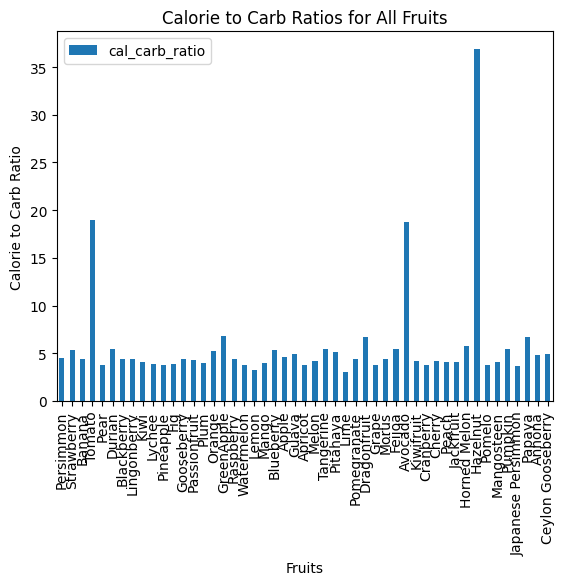

In [ ]:
fruit_df.plot.bar(x = 'name', y = 'cal_carb_ratio')
plt.xlabel('Fruits')
plt.ylabel('Calorie to Carb Ratio')
plt.title('Calorie to Carb Ratios for All Fruits')
plt.show()

In [ ]:
families = fruit_df['family'].unique()
families

array(['Ebenaceae', 'Rosaceae', 'Musaceae', 'Solanaceae', 'Malvaceae',
       'Ericaceae', 'Actinidiaceae', 'Sapindaceae', 'Bromeliaceae',
       'Moraceae', 'Grossulariaceae', 'Passifloraceae', 'Rutaceae',
       'Cucurbitaceae', 'Anacardiaceae', 'Myrtaceae', 'Cactaceae',
       'Lythraceae', 'Vitaceae', 'Lauraceae', 'Betulaceae', 'Clusiaceae',
       ' Ebenaceae', 'Caricaceae', 'Annonaceae', 'Salicaceae'],
      dtype=object)

In [ ]:
familygroup = fruit_df.groupby('family')


Text(0.5, 1.0, 'Calorie to Sugar Ratio for All Fruit Families')

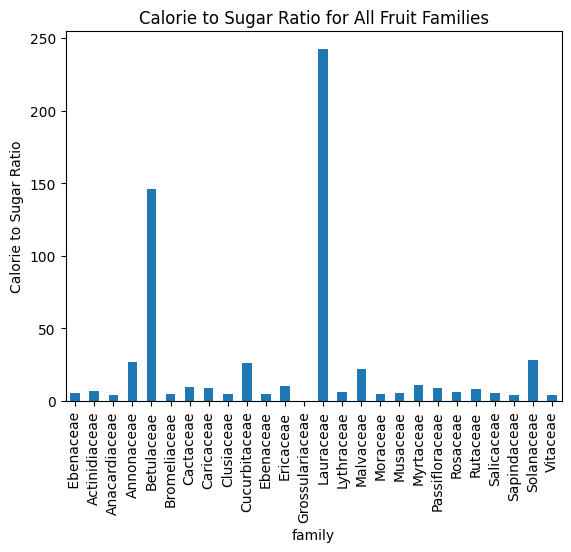

In [ ]:
avg_cal_sugar_ratio = familygroup['cal_sugar_ratio'].mean()
avg_cal_sugar_ratio.plot(kind = 'bar')
plt.ylabel('Calorie to Sugar Ratio')
plt.title('Calorie to Sugar Ratio for All Fruit Families')


Text(0.5, 1.0, 'Calorie to Carb Ratio for All Fruit Families')

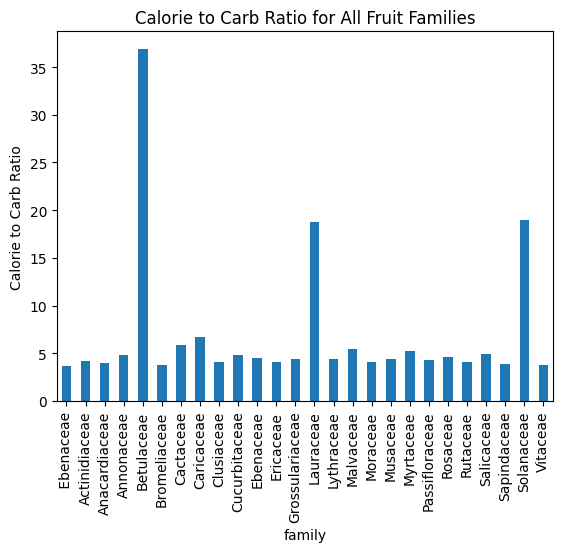

In [ ]:
avg_cal_carb_ratio = familygroup['cal_carb_ratio'].mean()
avg_cal_carb_ratio.plot(kind = 'bar')
plt.ylabel('Calorie to Carb Ratio')
plt.title('Calorie to Carb Ratio for All Fruit Families')